# Einflussanalyse der Merkmale auf den Fahrzeugpreis

In [39]:
import sys
import os

sys.path.append(
    os.path.abspath(
        os.path.join(os.getcwd(), "..")
    )
)

# Data
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import (
    ttest_ind,
    f_oneway,
    chi2_contingency,
    pearsonr,
    spearmanr
)

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Plot Settings
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

1. LOAD DATA UND DATA OVERVIEW

In [40]:
from db.data_loader import load_data

df = load_data()

df.head()

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.info()
df.shape

Rows: 1200
Columns: 13
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   datum                1200 non-null   str    
 1   marke                1200 non-null   str    
 2   modell               1200 non-null   str    
 3   preis_euro           1200 non-null   int64  
 4   verkaufszahl         1200 non-null   int64  
 5   kraftstoff           1200 non-null   str    
 6   getriebe             1200 non-null   str    
 7   hubraum_l            1200 non-null   float64
 8   bundesland           1200 non-null   str    
 9   kundenzufriedenheit  1200 non-null   float64
 10  jahr                 1200 non-null   int64  
 11  monat                1200 non-null   int64  
 12  wochentag            1200 non-null   str    
dtypes: float64(2), int64(4), str(7)
memory usage: 122.0 KB


(1200, 13)

1.1 EDA — Exploratory Data Analysis

In [41]:
print("Unique Marken:", df["marke"].nunique())
print("Unique Modelle:", df["modell"].nunique())

print(df["modell"].value_counts().head(20))
print(df["modell"].value_counts().tail(20))

Unique Marken: 5
Unique Modelle: 20
modell
E-Klasse     75
Golf         73
Q5           71
5Er          67
Grandland    67
Id.4         63
Mokka        63
A4           63
C-Klasse     61
Passat       60
E-Tron       59
Tiguan       59
Corsa        58
Astra        57
3Er          57
X5           55
I4           54
A6           47
Glc          46
Eqe          45
Name: count, dtype: int64
modell
E-Klasse     75
Golf         73
Q5           71
5Er          67
Grandland    67
Id.4         63
Mokka        63
A4           63
C-Klasse     61
Passat       60
E-Tron       59
Tiguan       59
Corsa        58
Astra        57
3Er          57
X5           55
I4           54
A6           47
Glc          46
Eqe          45
Name: count, dtype: int64


2. EINFLUSSANALYSE

2.1 Marke nach Preis

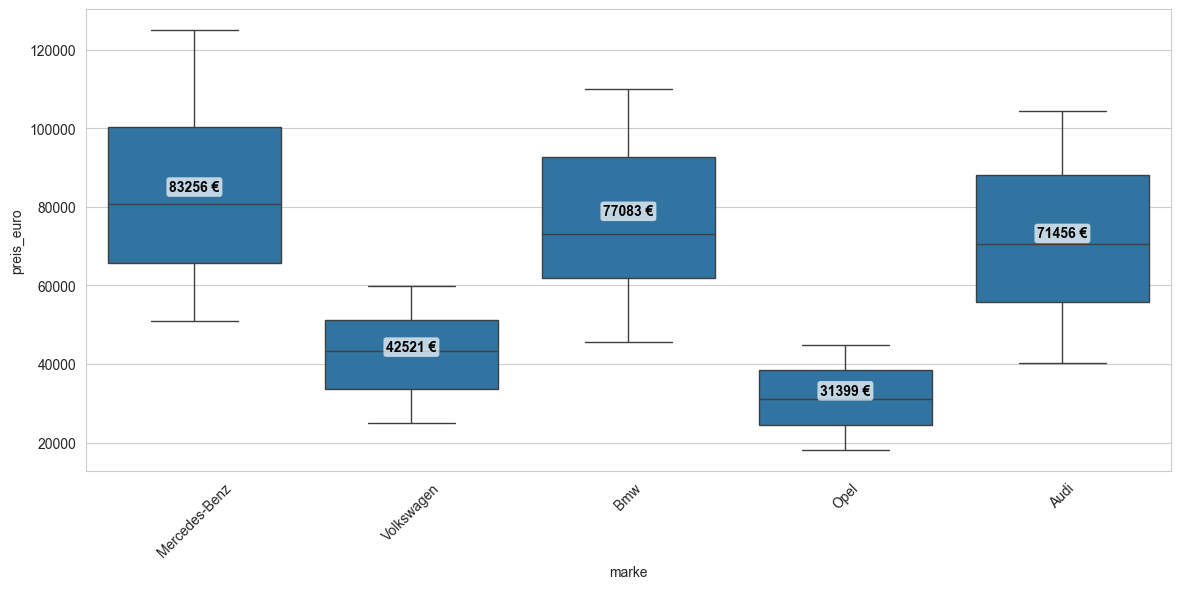

In [42]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x="marke", y="preis_euro")

means = df.groupby("marke")["preis_euro"].mean()
categories = df["marke"].unique() 


for i, category in enumerate(categories):
    mean_val = means[category]

   
    plt.text(
        x=i,
        y=mean_val,
        s=f"{mean_val:.0f} €", 
        fontweight="bold",
        color="black",
        ha="center",  
        va="bottom",  
        bbox=dict(
            facecolor="white", alpha=0.7, edgecolor="none", boxstyle="round,pad=0.2"
        ),
    )

plt.xticks(rotation=45)
plt.show()

2.2 Durchschnittliche Fahrzeugpreise nach Marke und Model

--------------------------------------------------
Durchschnittliche Fahrzeugpreise nach Marke:
marke
Mercedes-Benz    83255.546256
Bmw              77082.673820
Audi             71455.683333
Volkswagen       42521.003922
Opel             31398.665306
Name: preis_euro, dtype: float64
--------------------------------------------------


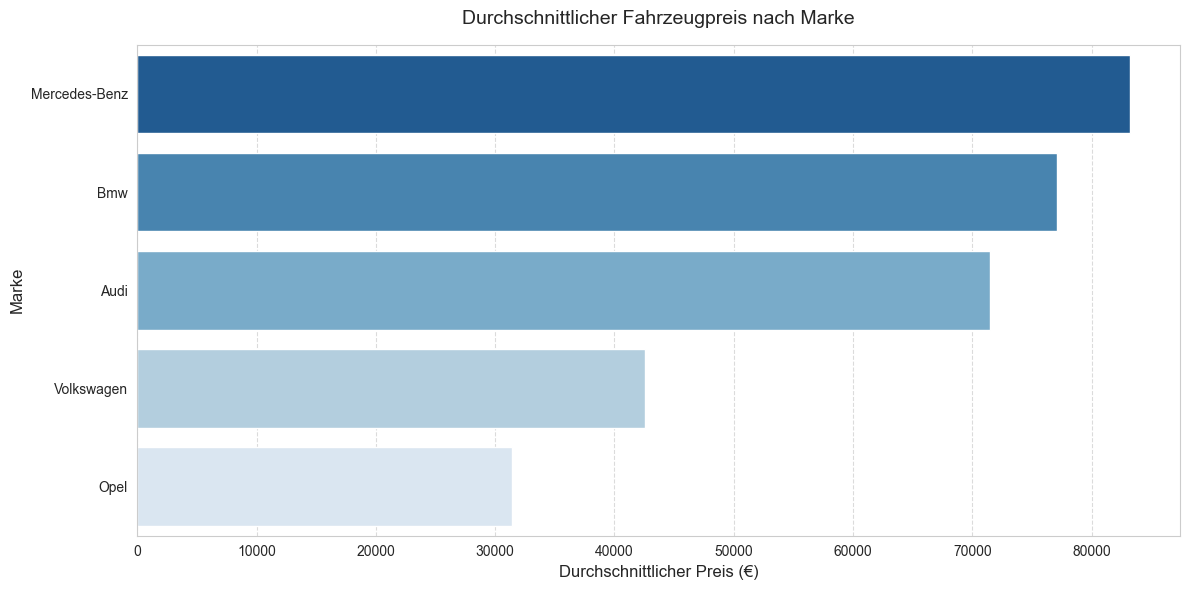

In [43]:
df = load_data()

brand_column = "marke" 
price_column = "preis_euro"

marke_preis = (
    df.groupby(brand_column)[price_column].mean().sort_values(ascending=False)
)

print("-" * 50)
print("Durchschnittliche Fahrzeugpreise nach Marke:")
print(marke_preis)
print("-" * 50)

plt.figure(figsize=(12, 6))

sns.barplot(x=marke_preis.values, y=marke_preis.index, palette="Blues_r")

plt.title("Durchschnittlicher Fahrzeugpreis nach Marke", fontsize=14, pad=15)
plt.xlabel("Durchschnittlicher Preis (€)", fontsize=12)
plt.ylabel("Marke", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

Durchschnittlicher Fahrzeugpreis nach Modell

--------------------------------------------------
Durchschnittliche Fahrzeugpreise für Mercedes-Benz nach Modell:
modell
Eqe         86685.644444
C-Klasse    84623.852459
E-Klasse    82452.640000
Glc         79394.608696
Name: preis_euro, dtype: float64
--------------------------------------------------


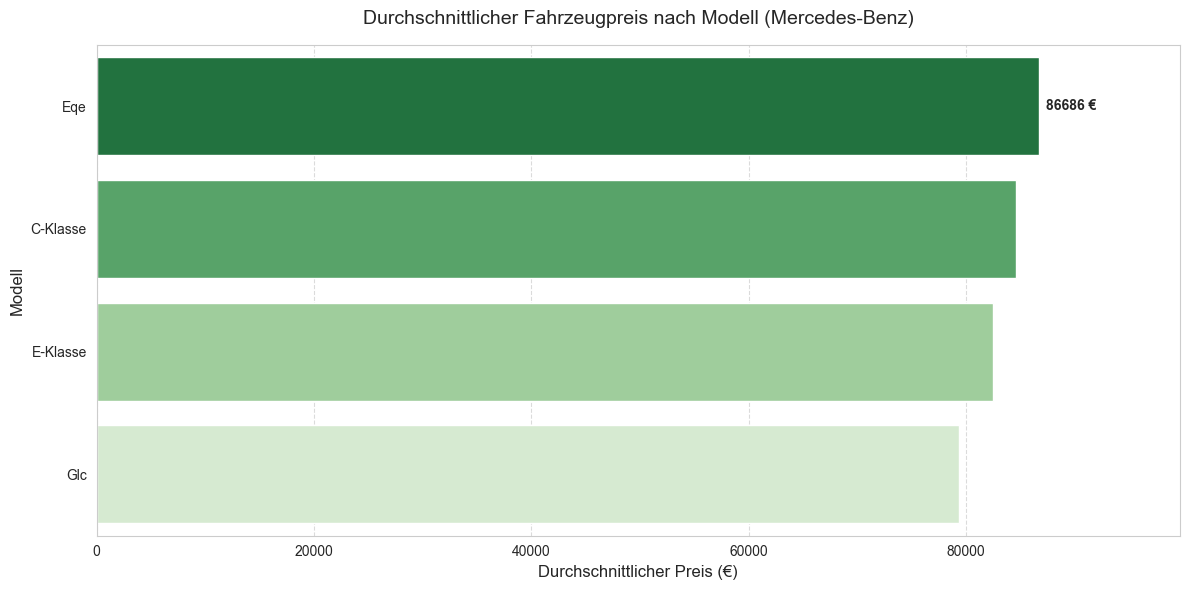

In [44]:
brand_column = "marke"
price_column = "preis_euro"
model_column = "modell" 

brand_filter = "Mercedes-Benz"

df_mercedes = df[df[brand_column] == brand_filter]

mercedes_models = (
    df_mercedes.groupby(model_column)[price_column]
    .mean()
    .sort_values(ascending=False)
)

print("-" * 50)
print(f"Durchschnittliche Fahrzeugpreise für {brand_filter} nach Modell:")
print(mercedes_models)
print("-" * 50)

plot_height = max(6, len(mercedes_models) * 0.4)
plt.figure(figsize=(12, plot_height))

ax = sns.barplot(
    x=mercedes_models.values, y=mercedes_models.index, palette="Greens_r"
)

ax.bar_label(
    ax.containers[0],
    fmt="%.0f €",  
    padding=5,
    fontsize=10,
    fontweight="bold",
)

plt.title(
    f"Durchschnittlicher Fahrzeugpreis nach Modell ({brand_filter})",
    fontsize=14,
    pad=15,
)
plt.xlabel("Durchschnittlicher Preis (€)", fontsize=12)
plt.ylabel("Modell", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.xlim(0, mercedes_models.max() * 1.15)

plt.tight_layout()
plt.show()

2.3 Kraftstoff nach Preis

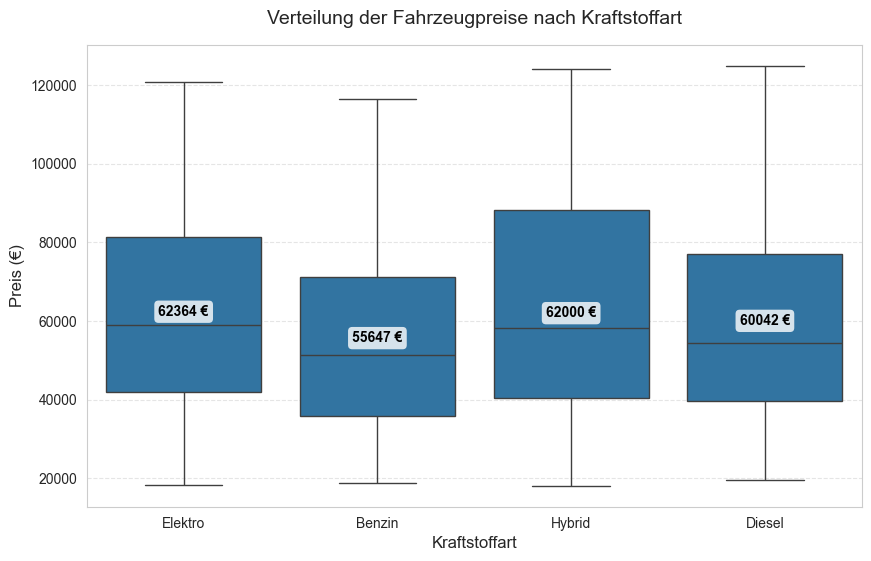

In [45]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="kraftstoff", y="preis_euro")

fuel_types = df["kraftstoff"].unique()
means = df.groupby("kraftstoff")["preis_euro"].mean()

for i, fuel in enumerate(fuel_types):
    mean_val = means[fuel]

    plt.text(
        x=i,  
        y=mean_val,  
        s=f"{mean_val:.0f} €",  
        fontweight="bold",
        color="black",
        ha="center",  
        va="center",  
        bbox=dict(
            facecolor="white", alpha=0.8, edgecolor="none", boxstyle="round,pad=0.3"
        ),
    )

plt.title("Verteilung der Fahrzeugpreise nach Kraftstoffart", fontsize=14, pad=15)
plt.xlabel("Kraftstoffart", fontsize=12)
plt.ylabel("Preis (€)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)  

plt.show()

In [46]:
fuel_stats = df.groupby("kraftstoff")["preis_euro"].agg(["mean", "count"])
print(fuel_stats)

                    mean  count
kraftstoff                     
Benzin      55646.662551    243
Diesel      60041.738956    249
Elektro     62363.666667    483
Hybrid      61999.920000    225


2.4 Getriebe nach Preis

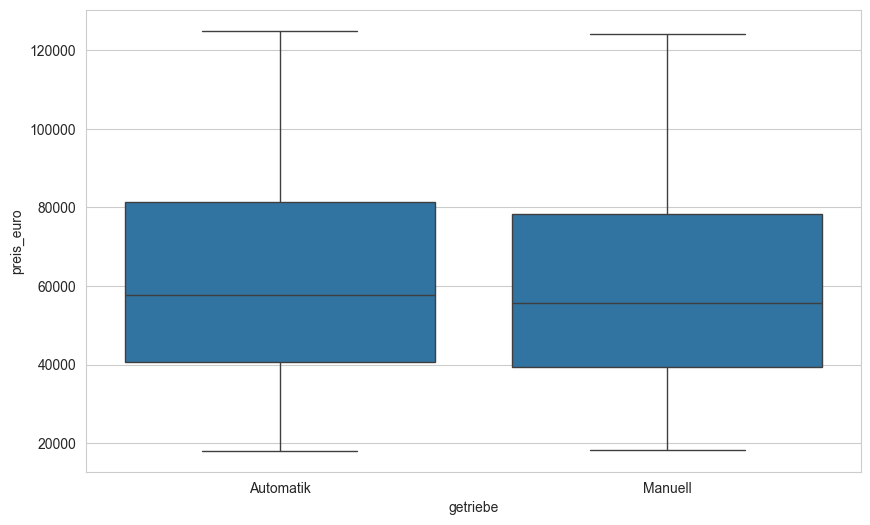

In [47]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="getriebe",
    y="preis_euro"
)

plt.show()

2.5 Hubraum  nach Preis

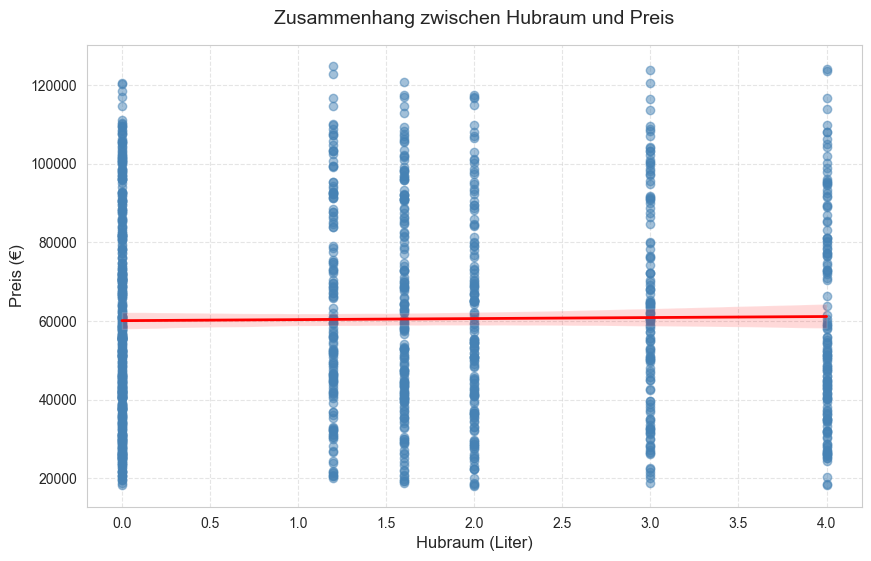

In [48]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="hubraum_l",
    y="preis_euro",
    scatter_kws={
        "alpha": 0.5,
        "color": "steelblue",
    }, 
    line_kws={"color": "red", "lw": 2},  
)

plt.title("Zusammenhang zwischen Hubraum und Preis", fontsize=14, pad=15)
plt.xlabel("Hubraum (Liter)", fontsize=12)
plt.ylabel("Preis (€)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

2.6 Verkaufszahl nach Preis

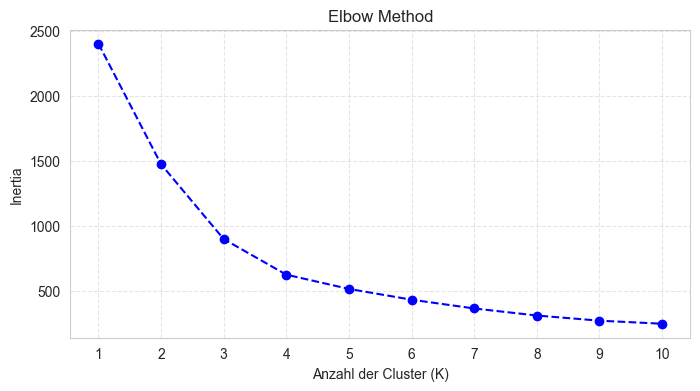


Mittelwerte für jeden Cluster:
           preis_euro  verkaufszahl
cluster                            
0        46239.451613      7.098790
1        93978.441176      4.782353
2        48507.491758      2.458791


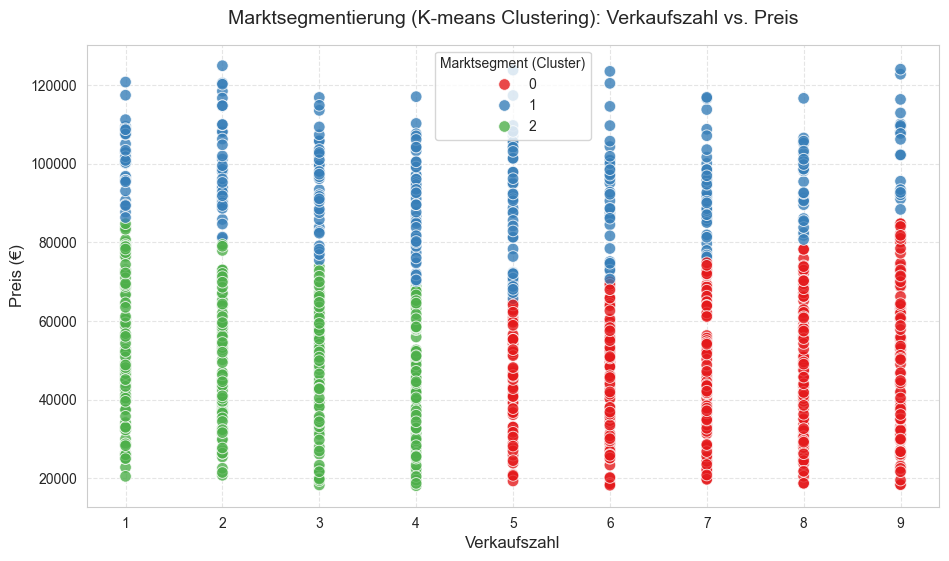

In [49]:
features = ["verkaufszahl", "preis_euro"]
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# ELBOW METHOD
# ==========================================
inertia = []
K_range = range(1, 11)  

for k in K_range:
    kmeans_elbow = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_elbow.fit(X_scaled)
    inertia.append(kmeans_elbow.inertia_)

# Visualiz.
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker="o", linestyle="--", color="b")
plt.title("Elbow Method", fontsize=12)
plt.xlabel("Anzahl der Cluster (K)", fontsize=10)
plt.ylabel("Inertia", fontsize=10)
plt.xticks(K_range)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show() 
# ==========================================

optimal_k = 3 
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=df,
    x="verkaufszahl",
    y="preis_euro",
    hue="cluster",
    palette="Set1",
    s=70,
    alpha=0.8,
)

plt.title(
    "Marktsegmentierung (K-means Clustering): Verkaufszahl vs. Preis",
    fontsize=14,
    pad=15,
)
plt.xlabel("Verkaufszahl", fontsize=12)
plt.ylabel("Preis (€)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Marktsegment (Cluster)")

print("\nMittelwerte für jeden Cluster:")
print(df.groupby("cluster")[["preis_euro", "verkaufszahl"]].mean())

plt.show()

2.7 Konfidenzintervall

In [50]:
from scipy.stats import t
from scipy.stats import sem

preise = df["preis_euro"]

n = len(preise)
mean = preise.mean()
se = sem(preise)

ci = t.interval(
    confidence=0.95,
    df=n - 1,
    loc=mean,
    scale=se
)

print(f"Mittelwert: {mean:.2f}")
print(
    f"95%-Konfidenzintervall: "
    f"[{ci[0]:.2f}, {ci[1]:.2f}]"
)

Mittelwert: 60453.47
95%-Konfidenzintervall: [58983.85, 61923.10]


Ergebnisse:  
Der berechnete Mittelwert (mean) stammt aus Ihrer Stichprobe. Das Konfidenzintervall (KI) gibt die statistische Präzision dieses Mittelwerts an.

Es beschreibt den Bereich, der bei einer hypothetischen unendlichen Wiederholung der Stichprobenziehung in 95 % der Fälle den wahren Mittelwert der Grundgesamtheit (aller Autoverkäufe in Deutschland) einschließt.

3.  ZUSAMMENHANGSANALYSE

Erstellung der Korrelationsmatrix

In [51]:
numerical_columns = [
    "preis_euro",
    "verkaufszahl",
    "hubraum_l",
    "kundenzufriedenheit",
    "jahr",
    "monat",
]

corr_matrix = df[numerical_columns].corr(method="pearson")

corr_matrix

,preis_euro,verkaufszahl,hubraum_l,kundenzufriedenheit,jahr,monat
preis_euro,1.000000,-0.081754,0.013972,0.025650,0.057965,-0.008052
verkaufszahl,-0.081754,1.000000,0.007366,-0.074914,-0.021620,-0.004276
hubraum_l,0.013972,0.007366,1.000000,-0.015391,-0.011348,-0.049634
kundenzufriedenheit,0.025650,-0.074914,-0.015391,1.000000,0.047530,0.044849
jahr,0.057965,-0.021620,-0.011348,0.047530,1.000000,-0.010622
monat,-0.008052,-0.004276,-0.049634,0.044849,-0.010622,1.000000


Rangkorrelationskoeffizient nach Spearman

In [52]:
corr_spearman = (
    df[numerical_columns]
    .corr(method="spearman")
)

corr_spearman

,preis_euro,verkaufszahl,hubraum_l,kundenzufriedenheit,jahr,monat
preis_euro,1.000000,-0.081548,0.012829,0.020314,0.056684,-0.009373
verkaufszahl,-0.081548,1.000000,0.009690,-0.076122,-0.021703,-0.002699
hubraum_l,0.012829,0.009690,1.000000,-0.016723,-0.013201,-0.048630
kundenzufriedenheit,0.020314,-0.076122,-0.016723,1.000000,0.047233,0.044873
jahr,0.056684,-0.021703,-0.013201,0.047233,1.000000,-0.008402
monat,-0.009373,-0.002699,-0.048630,0.044873,-0.008402,1.000000


Ergebnisse:  
Die Rangkorrelationsanalyse nach Spearman zeigt für alle numerischen Variablen lediglich sehr geringe Korrelationskoeffizienten (|ρ| < 0,1). Somit konnte kein relevanter monotoner Zusammenhang zwischen den untersuchten numerischen Merkmalen und dem Fahrzeugpreis festgestellt werden. Das Jahr weist mit ρ = 0,057 zwar den höchsten positiven Koeffizienten auf, dieser ist jedoch praktisch vernachlässigbar.

Variable	Spearman mit preis_euro  
verkaufszahl	-0.0815  
jahr	0.0567  
kundenzufriedenheit	0.0203  
hubraum_l	0.0128  
monat	-0.0094  

Scatterplot Analyse: Preis vs numerische Variablen

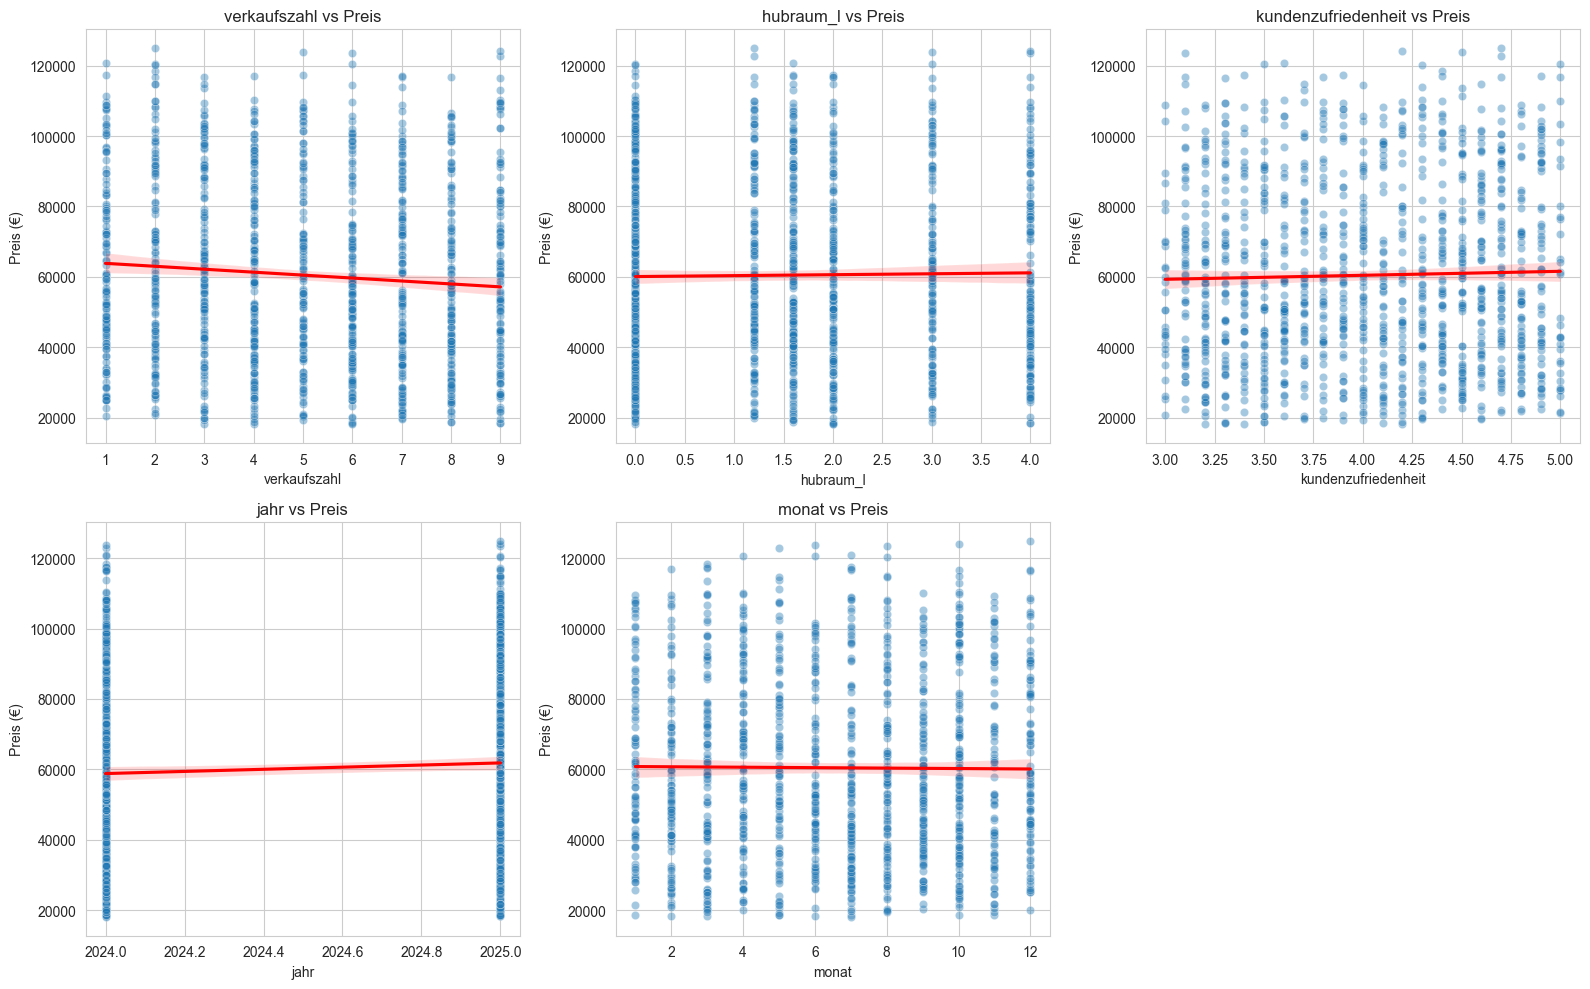

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_columns = [
    "preis_euro",
    "verkaufszahl",
    "hubraum_l",
    "kundenzufriedenheit",
    "jahr",
    "monat",
]

# Zielvariable
target = "preis_euro"

features = [
    col for col in numerical_columns
    if col != target
]

plt.figure(figsize=(16, 10))

for i, feature in enumerate(features):
    plt.subplot(2, 3, i + 1)

    sns.scatterplot(
        data=df,
        x=feature,
        y=target,
        alpha=0.4
    )

    sns.regplot(
        data=df,
        x=feature,
        y=target,
        scatter=False,
        color="red"
    )

    plt.title(f"{feature} vs Preis")
    plt.xlabel(feature)
    plt.ylabel("Preis (€)")

plt.tight_layout()
plt.show()

Mutual Information Ranking

In [ ]:
from sklearn.feature_selection import mutual_info_regression


# Zielvariable
target = "preis_euro"

# Features (nur numerisch + encodierte kategoriale später möglich)
features = [
    "verkaufszahl",
    "hubraum_l",
    "kundenzufriedenheit",
    "jahr",
    "monat"
]

# X und y
X = df[features]
y = df[target]

# Mutual Information berechnen
mi_scores = mutual_info_regression(X, y, random_state=42)

# DataFrame erstellen
mi_df = pd.DataFrame({
    "Feature": features,
    "Mutual_Information": mi_scores
})

# Sortieren
mi_df = mi_df.sort_values(by="Mutual_Information", ascending=False)

display(mi_df)

,Feature,Mutual_Information
1,hubraum_l,0.013275
2,kundenzufriedenheit,0.004431
0,verkaufszahl,0.000000
3,jahr,0.000000
4,monat,0.000000


Kategoriale Variablen → Kundenzufriedenheit  
ANOVA  
η² (Eta Squared) 

In [53]:
from scipy.stats import f_oneway
import numpy as np

def anova_eta_squared(df, cat_col, target):

    groups = [
        group[target].values
        for _, group in df.groupby(cat_col)
    ]

    f_stat, p_value = f_oneway(*groups)

    grand_mean = df[target].mean()

    ss_between = sum(
        len(group) *
        (group.mean() - grand_mean) ** 2
        for _, group in df.groupby(cat_col)[target]
    )

    ss_total = sum(
        (df[target] - grand_mean) ** 2
    )

    eta_sq = ss_between / ss_total

    return f_stat, p_value, eta_sq

In [54]:
categorical = [
    "marke",
    "modell",
    "kraftstoff",
    "getriebe",
    "bundesland",
    "wochentag"
]

results = []

for col in categorical:

    f, p, eta = anova_eta_squared(
        df,
        col,
        "preis_euro"
    )

    results.append([
        col,
        f,
        p,
        eta
    ])

importance_df = pd.DataFrame(
    results,
    columns=[
        "Variable",
        "F",
        "p_value",
        "eta_squared"
    ]
)

importance_df = (
    importance_df
    .sort_values(
        "eta_squared",
        ascending=False
    )
)

importance_df

,Variable,F,p_value,eta_squared
1,modell,103.325996,5.406159e-235,0.624586
0,marke,486.927928,4.545563e-249,0.619755
2,kraftstoff,3.968605,7.908118e-03,0.009857
5,wochentag,1.590960,1.461970e-01,0.007938
4,bundesland,0.499445,7.768342e-01,0.002087
3,getriebe,1.554300,2.127455e-01,0.001296


Ergebnisse:
Modell
Die ANOVA zeigt einen hochsignifikanten Einfluss des Fahrzeugmodells auf den Preis (p < 0,001). Die Effektstärke beträgt η² = 0,625. Somit können etwa 62,5 % der Preisvarianz durch das Fahrzeugmodell erklärt werden. Das Modell stellt den wichtigsten Einflussfaktor für die Preisvorhersage dar.

Marke
Die Fahrzeugmarke weist ebenfalls einen hochsignifikanten Einfluss auf den Fahrzeugpreis auf (p < 0,001). Mit einer Effektstärke von η² = 0,620 erklärt die Marke rund 62,0 % der Preisvarianz und gehört damit zu den wichtigsten Prädiktoren.

Kraftstoff
Der Kraftstofftyp zeigt zwar einen statistisch signifikanten Zusammenhang mit dem Fahrzeugpreis (p = 0,008), die Effektstärke ist jedoch mit η² = 0,010 sehr gering. Der praktische Einfluss auf den Preis ist daher schwach.

Wochentag
Für den Wochentag konnte kein statistisch signifikanter Einfluss auf den Fahrzeugpreis festgestellt werden (p = 0,146; η² = 0,008).

Bundesland
Zwischen Bundesland und Fahrzeugpreis besteht kein statistisch signifikanter Zusammenhang (p = 0,777; η² = 0,002). Der Einfluss auf die Preisbildung ist vernachlässigbar.

Getriebe
Die Getriebeart zeigt keinen statistisch signifikanten Einfluss auf den Fahrzeugpreis (p = 0,213; η² = 0,001). Der Beitrag zur Erklärung der Preisvarianz ist praktisch nicht vorhanden.

Variable p-Wert	η²	Einfluss auf den Preis  
Modell	< 0.001	0.625	sehr stark  
Marke	< 0.001	0.620	sehr stark  
Kraftstoff	0.008	0.010	schwach  
Wochentag	0.146	0.008	kein signifikanter Einfluss  
Bundesland	0.777	0.002	kein signifikanter Einfluss  
Getriebe	0.213	0.001	kein signifikanter Einfluss